# 📰 Phase 7: POS Tagging & Analisis Linguistik — LPDP

## 🎯 Tujuan Notebook
Melakukan Part-of-Speech (POS) Tagging dan analisis linguistik mendalam dari dataset artikel LPDP yang sudah melalui pipeline preprocessing, feature extraction, dan NER.

## Alur Proses:
| Langkah | Deskripsi |
|---|---|
| 1️⃣ Load Dataset | Muat hasil Phase 6 (`dataset_lpdp_preprocessed.csv` + `ner_results.csv`) |
| 2️⃣ Setup Stanza | Install & download model Bahasa Indonesia (~500MB) |
| 3️⃣ POS Tagging | Tagging seluruh artikel menggunakan Stanza |
| 4️⃣ Analisis Distribusi POS | Distribusi NOUN, VERB, ADJ, ADV, dll. per artikel |
| 5️⃣ Analisis per Sentimen | Pola POS tag yang dominan pada tiap kelas sentimen |
| 6️⃣ Analisis per Topik | Karakteristik linguistik per topik BERTopic |
| 7️⃣ Visualisasi | Bar chart, heatmap, word cloud per POS |
| 8️⃣ Export | Simpan hasil POS tag ke CSV & Excel |

**Kelompok 5:** Amel, Celine, Iqbal, Nida, Salwa 

**PIC Phase 7:** Amel 

**Input:**
- `dataset_lpdp_preprocessed.csv` — 1.038 artikel + `text_clean`, `Sentiment`, `topic_label` (Phase 4 output)
- `output_ner_visualisasi/ner_results.csv` — hasil NER per artikel (Phase 6 output)

**Output Folder:** `output_pos_tagging/`
- `pos_results.csv` — hasil POS tag per token per artikel
- `pos_summary.xlsx` — ringkasan distribusi POS per artikel & per topik
- `*.png` — semua grafik visualisasi

## 📦 Install Dependencies

In [1]:
import sys, subprocess

packages = [
    "stanza",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "wordcloud",
    "openpyxl",
    "tqdm",
    "scikit-learn",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", *packages])
print("✅ Semua package berhasil diinstall!")

✅ Semua package berhasil diinstall!


## 📦 Import Libraries

In [2]:
# === Standard Library ===
import os
import re
import warnings
from pathlib import Path
from collections import Counter, defaultdict

# === Data Manipulation ===
import pandas as pd
import numpy as np

# === NLP ===
import stanza
from tqdm.auto import tqdm

# === Visualization ===
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

# === Settings ===
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print(f"✅ Semua library berhasil diimport!")
print(f"   pandas  : {pd.__version__}")
print(f"   stanza  : {stanza.__version__}")

c:\Coding\pba\tugas-klp\PBA\Project A\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Semua library berhasil diimport!
   pandas  : 3.0.2
   stanza  : 1.11.1


## 📂 Load Dataset & Setup Output Folder

In [3]:
# === Path Konfigurasi ===
PREPROCESSED_FILE = "dataset_lpdp_preprocessed.csv"
NER_RESULTS_FILE  = "output_ner_visualisasi/ner_results.csv"
OUTPUT_DIR        = Path("output_pos_tagging")
OUTPUT_DIR.mkdir(exist_ok=True)

# === Load Dataset Utama ===
df = pd.read_csv(PREPROCESSED_FILE)
df['topic_label'] = df['label_name']
print(f"📂 Dataset dimuat: {PREPROCESSED_FILE}")
print(f"   Shape  : {df.shape}")
print(f"   Kolom  : {df.columns.tolist()}")

# === Load Hasil NER (Phase 6) ===
df_ner = pd.read_csv(NER_RESULTS_FILE)
print(f"\n📂 NER results dimuat: {NER_RESULTS_FILE}")
print(f"   Shape  : {df_ner.shape}")

# === Kolom konten untuk POS (pakai Content asli) ===
content_col = 'Content'

print(f"\n📊 Distribusi Sentimen:")
print(df['Sentiment'].value_counts())
print(f"\n📊 Distribusi Topik:")
print(df['topic_label'].value_counts(dropna=False))

📂 Dataset dimuat: dataset_lpdp_preprocessed.csv
   Shape  : (1038, 15)
   Kolom  : ['doc_id', 'Title', 'Release Date', 'URL', 'Publisher', 'PiC', 'Valid?', 'Sentiment', 'Notes', 'Actual_URL', 'Content', 'label_4', 'label_name', 'text_clean', 'topic_label']

📂 NER results dimuat: output_ner_visualisasi/ner_results.csv
   Shape  : (32202, 6)

📊 Distribusi Sentimen:
Sentiment
Positive    385
Neutral     342
Negative    311
Name: count, dtype: int64

📊 Distribusi Topik:
topic_label
Kebijakan & Prioritas Program    553
Kewajiban & Sanksi Penerima      147
Pendaftaran & Seleksi LPDP       140
NaN                              101
Kontroversi Penerima Beasiswa     97
Name: count, dtype: int64


## 🏷️ Part 1: Setup Stanza & Download Model

### 1.1 Download Model Bahasa Indonesia

Menggunakan **Stanza** — library NLP dari Stanford yang mendukung Bahasa Indonesia dengan model pre-trained berbasis neural network.

| POS Tag | Deskripsi | Contoh |
|---|---|---|
| NOUN | Kata benda | beasiswa, penerima, program |
| VERB | Kata kerja | mendaftar, menerima, melaporkan |
| ADJ | Kata sifat | unggulan, afirmatif, berprestasi |
| ADV | Kata keterangan | sangat, sudah, belum |
| PROPN | Nama proper | LPDP, Indonesia, Jokowi |
| NUM | Angka/bilangan | 5.000, satu, pertama |
| ADP | Preposisi | di, ke, dari, untuk |
| CCONJ | Konjungsi koordinat | dan, atau, tetapi |
| PRON | Kata ganti | mereka, kami, ini |
| DET | Determiner | para, semua, setiap |

In [4]:
# === Download model Bahasa Indonesia ===
# ⏱️ Estimasi waktu: ~5-10 menit (download ~500MB, hanya perlu sekali)
print("📥 Mengunduh model Stanza Bahasa Indonesia...")
print("   (Proses ini hanya perlu dilakukan sekali, ~500MB)")

stanza.download('id', verbose=False)
print("✅ Model Stanza Bahasa Indonesia berhasil diunduh!")

📥 Mengunduh model Stanza Bahasa Indonesia...
   (Proses ini hanya perlu dilakukan sekali, ~500MB)
✅ Model Stanza Bahasa Indonesia berhasil diunduh!


### 1.2 Inisialisasi Pipeline Stanza

In [5]:
# === Inisialisasi pipeline Stanza ===
# Prosesor yang diaktifkan: tokenize, mwt, pos
print("⚙️  Menginisialisasi pipeline Stanza...")

nlp = stanza.Pipeline(
    lang='id',
    processors='tokenize,mwt,pos',
    verbose=False
)

print("✅ Pipeline Stanza berhasil diinisialisasi!")

# === Test pipeline pada kalimat contoh ===
print("\n🧪 Test POS Tagging pada kalimat contoh...")
sample_sentence = "LPDP memberikan beasiswa kepada mahasiswa berprestasi dari seluruh Indonesia."
doc_test = nlp(sample_sentence)

print(f"   Kalimat: '{sample_sentence}'")
print(f"   {'Token':<20} {'POS':<10} {'XPOS':<10}")
print(f"   {'-'*40}")
for sent in doc_test.sentences:
    for word in sent.words:
        print(f"   {word.text:<20} {word.upos:<10} {word.xpos:<10}")

⚙️  Menginisialisasi pipeline Stanza...
✅ Pipeline Stanza berhasil diinisialisasi!

🧪 Test POS Tagging pada kalimat contoh...
   Kalimat: 'LPDP memberikan beasiswa kepada mahasiswa berprestasi dari seluruh Indonesia.'
   Token                POS        XPOS      
   ----------------------------------------
   LPDP                 PROPN      X--       
   memberikan           VERB       VSA       
   beasiswa             NOUN       NSD       
   kepada               ADP        R--       
   mahasiswa            NOUN       NSD       
   berprestasi          VERB       VSA       
   dari                 ADP        R--       
   seluruh              DET        B--       
   Indonesia            PROPN      NSD       
   .                    PUNCT      Z--       


## 🔖 Part 2: Jalankan POS Tagging pada Seluruh Artikel

### 2.1 POS Tagging Loop

⏱️ **Estimasi waktu:** ~20–40 menit di CPU untuk 1.038 artikel.  
Notebook ini menyimpan progress ke `output_pos_tagging/pos_results.csv` setiap 50 artikel — aman jika proses terputus.

In [6]:
POS_OUTPUT_FILE = OUTPUT_DIR / "pos_results.csv"
SAVE_EVERY      = 50
MAX_WORDS       = 300
BATCH_SIZE      = 16 

def truncate_text(text, max_words=MAX_WORDS):
    """Potong teks ke max_words kata untuk efisiensi POS tagging."""
    words = str(text).split()
    return ' '.join(words[:max_words])

# === Hapus file kosong jika ada ===
if POS_OUTPUT_FILE.exists() and POS_OUTPUT_FILE.stat().st_size < 10:
    POS_OUTPUT_FILE.unlink()
    print("🗑️ File kosong dihapus, mulai dari awal.")

# === Resume dari checkpoint jika ada ===
if POS_OUTPUT_FILE.exists():
    df_pos_done = pd.read_csv(POS_OUTPUT_FILE)
    done_ids    = set(df_pos_done['doc_id'].tolist())
    print(f"⏩ Resume: {len(done_ids)} artikel sudah selesai.")
else:
    df_pos_done = pd.DataFrame()
    done_ids    = set()

# === Test pada artikel pertama ===
print("\n🧪 Test POS Tagging pada artikel pertama...")
sample_text = truncate_text(df[content_col].iloc[0])
try:
    doc_sample   = nlp(sample_text)
    total_tokens = sum(len(s.words) for s in doc_sample.sentences)
    print(f"✅ POS Tagging berjalan! Token ditemukan: {total_tokens}")
    print(f"   Contoh 5 token pertama:")
    for sent in doc_sample.sentences:
        for word in sent.words[:5]:
            print(f"   {word.text:<20} → {word.upos}")
        break
except Exception as e:
    print(f"❌ POS Tagging gagal: {e}")
    raise

# === Loop POS Tagging — Batch Processing ===
df_todo = df[~df['doc_id'].isin(done_ids)].reset_index(drop=True)
print(f"\n📋 Artikel yang akan diproses : {len(df_todo)} dari {len(df)} total")
print(f"   Batch size               : {BATCH_SIZE} artikel per batch")
print(f"   Estimasi batch           : {len(df_todo) // BATCH_SIZE + 1} batch")

results = []
for batch_start in tqdm(range(0, len(df_todo), BATCH_SIZE), desc="POS Tagging Progress"):
    batch = df_todo.iloc[batch_start : batch_start + BATCH_SIZE]
    texts = [truncate_text(row[content_col]) for _, row in batch.iterrows()]
    meta  = [
        (row['doc_id'], row.get('Sentiment'), row.get('topic_label'))
        for _, row in batch.iterrows()
    ]

    try:
        docs = [nlp(text) for text in texts]
    except Exception:
        docs = [None] * len(texts)

    for doc, (doc_id, sentiment, topic_label) in zip(docs, meta):
        if doc is None:
            continue
        for sent_idx, sent in enumerate(doc.sentences):
            for word in sent.words:
                results.append({
                    'doc_id'      : doc_id,
                    'Sentiment'   : sentiment,
                    'topic_label' : topic_label,
                    'sent_idx'    : sent_idx,
                    'token'       : word.text,
                    'upos'        : word.upos,
                    'xpos'        : word.xpos,
                })

    # Simpan checkpoint setiap SAVE_EVERY artikel
    articles_done = batch_start + len(batch)
    if articles_done % SAVE_EVERY < BATCH_SIZE or articles_done >= len(df_todo):
        df_batch   = pd.DataFrame(results)
        df_all_pos = pd.concat([df_pos_done, df_batch], ignore_index=True)
        df_all_pos.to_csv(POS_OUTPUT_FILE, index=False)

# === Load hasil final ===
df_pos = pd.read_csv(POS_OUTPUT_FILE)


print(f"\n✅ POS Tagging selesai!")
print(f"   Total token ditemukan : {len(df_pos):,}")
print(f"   Total artikel diproses: {df_pos['doc_id'].nunique()}")
df_pos.head(10)

⏩ Resume: 1038 artikel sudah selesai.

🧪 Test POS Tagging pada artikel pertama...
✅ POS Tagging berjalan! Token ditemukan: 358
   Contoh 5 token pertama:
   Cegah                → PROPN
   kolusi-nepotisme     → NOUN
   ,                    → PUNCT
   program              → NOUN
   LPDP                 → PROPN

📋 Artikel yang akan diproses : 0 dari 1038 total
   Batch size               : 16 artikel per batch
   Estimasi batch           : 1 batch


POS Tagging Progress: 0it [00:00, ?it/s]



✅ POS Tagging selesai!
   Total token ditemukan : 338,257
   Total artikel diproses: 1038


,doc_id,Sentiment,topic_label,sent_idx,token,upos,xpos,feats
0,0,Negative,Kebijakan & Prioritas Program,0,Cegah,PROPN,VSA,NaN
1,0,Negative,Kebijakan & Prioritas Program,0,kolusi-nepotisme,NOUN,X--,NaN
2,0,Negative,Kebijakan & Prioritas Program,0,",",PUNCT,Z--,NaN
3,0,Negative,Kebijakan & Prioritas Program,0,program,NOUN,NSD,Number=Sing
4,0,Negative,Kebijakan & Prioritas Program,0,LPDP,PROPN,X--,NaN
5,0,Negative,Kebijakan & Prioritas Program,0,dinilai,VERB,VSP,Mood=Ind|Voice=Pass
6,0,Negative,Kebijakan & Prioritas Program,0,perlu,ADV,VSA,NaN
7,0,Negative,Kebijakan & Prioritas Program,0,perketat,VERB,VSA,Mood=Ind|Voice=Act
8,0,Negative,Kebijakan & Prioritas Program,0,seleksi,NOUN,NSD,Number=Sing
9,0,Negative,Kebijakan & Prioritas Program,0,Jakarta,PROPN,NSD,NaN


### 2.2 Statistik Dasar Hasil POS Tagging

In [7]:
# === Distribusi POS tag secara keseluruhan ===
pos_counts = df_pos['upos'].value_counts()
total_tokens = len(df_pos)

print(f"📊 Distribusi POS Tag — Total {total_tokens:,} token dari {df_pos['doc_id'].nunique()} artikel")
print(f"\n   {'POS Tag':<12} {'Jumlah':>10} {'Persentase':>12}")
print(f"   {'-'*36}")
for pos, cnt in pos_counts.items():
    print(f"   {pos:<12} {cnt:>10,} {cnt/total_tokens*100:>11.1f}%")

print(f"\n📊 Rata-rata token per artikel: {total_tokens / df_pos['doc_id'].nunique():.1f}")

📊 Distribusi POS Tag — Total 338,257 token dari 1038 artikel

   POS Tag          Jumlah   Persentase
   ------------------------------------
   NOUN             78,235        23.1%
   PROPN            62,209        18.4%
   PUNCT            48,832        14.4%
   VERB             36,568        10.8%
   ADP              26,998         8.0%
   PRON             16,450         4.9%
   ADJ              13,368         4.0%
   NUM              10,457         3.1%
   ADV              10,202         3.0%
   DET               8,855         2.6%
   CCONJ             8,154         2.4%
   SCONJ             6,490         1.9%
   AUX               5,861         1.7%
   PART              3,755         1.1%
   X                 1,619         0.5%
   SYM                 193         0.1%
   INTJ                 11         0.0%

📊 Rata-rata token per artikel: 325.9


## 📊 Part 3: Analisis Distribusi POS Tag

### 3.1 Distribusi POS Tag Overall

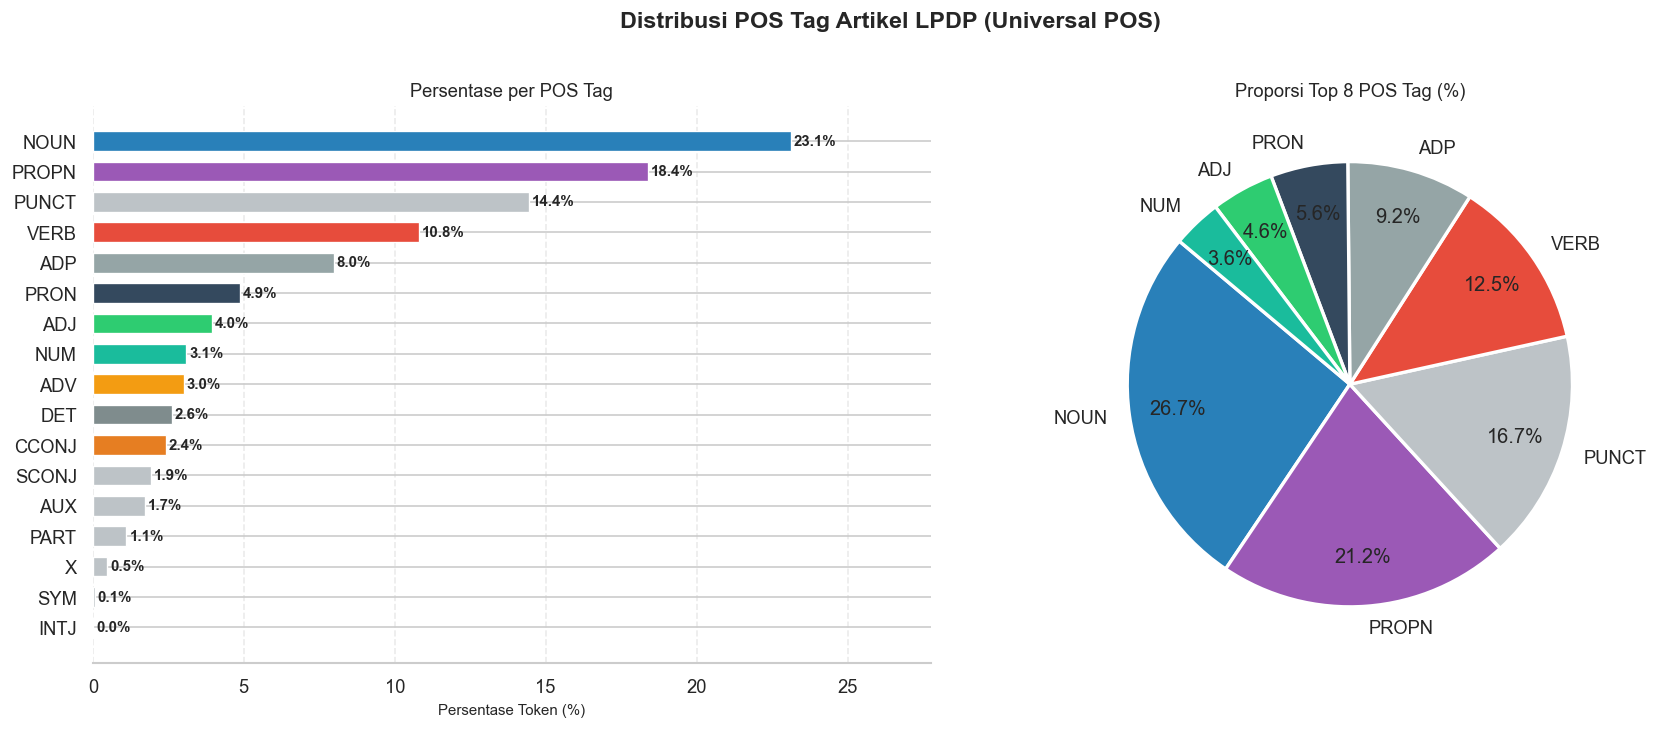

💾 Disimpan: output_pos_tagging\pos_distribusi_overall.png


In [8]:
PALETTE_POS = {
    'NOUN' : '#2980b9',
    'VERB' : '#e74c3c',
    'ADJ'  : '#2ecc71',
    'ADV'  : '#f39c12',
    'PROPN': '#9b59b6',
    'NUM'  : '#1abc9c',
    'ADP'  : '#95a5a6',
    'CCONJ': '#e67e22',
    'PRON' : '#34495e',
    'DET'  : '#7f8c8d',
}

pos_pct = (pos_counts / total_tokens * 100).reset_index()
pos_pct.columns = ['upos', 'pct']
pos_pct = pos_pct.sort_values('pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Distribusi POS Tag Artikel LPDP (Universal POS)', fontsize=14, fontweight='bold', y=1.01)

# --- Horizontal Bar Chart ---
colors = [PALETTE_POS.get(p, '#bdc3c7') for p in pos_pct['upos']]
bars = axes[0].barh(
    pos_pct['upos'], pos_pct['pct'],
    color=colors, edgecolor='white', linewidth=0.8, height=0.65
)
for bar, val in zip(bars, pos_pct['pct']):
    axes[0].text(
        bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%', va='center', ha='left', fontsize=9, fontweight='bold'
    )
axes[0].set_title('Persentase per POS Tag', fontsize=11)
axes[0].set_xlabel('Persentase Token (%)', fontsize=9)
axes[0].set_xlim(0, pos_pct['pct'].max() * 1.2)
axes[0].spines[['top', 'right', 'left']].set_visible(False)
axes[0].xaxis.grid(True, linestyle='--', alpha=0.4)
axes[0].set_axisbelow(True)

# --- Pie Chart (top 8 POS) ---
top8 = pos_pct.sort_values('pct', ascending=False).head(8)
colors_pie = [PALETTE_POS.get(p, '#bdc3c7') for p in top8['upos']]
axes[1].pie(
    top8['pct'],
    labels=top8['upos'],
    colors=colors_pie,
    autopct='%1.1f%%', startangle=140,
    pctdistance=0.78, labeldistance=1.1,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporsi Top 8 POS Tag (%)', fontsize=11)

plt.tight_layout()
out_path = OUTPUT_DIR / 'pos_distribusi_overall.png'
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f"💾 Disimpan: {out_path}")

### 3.2 Top Kata per POS Tag Utama (NOUN, VERB, ADJ)

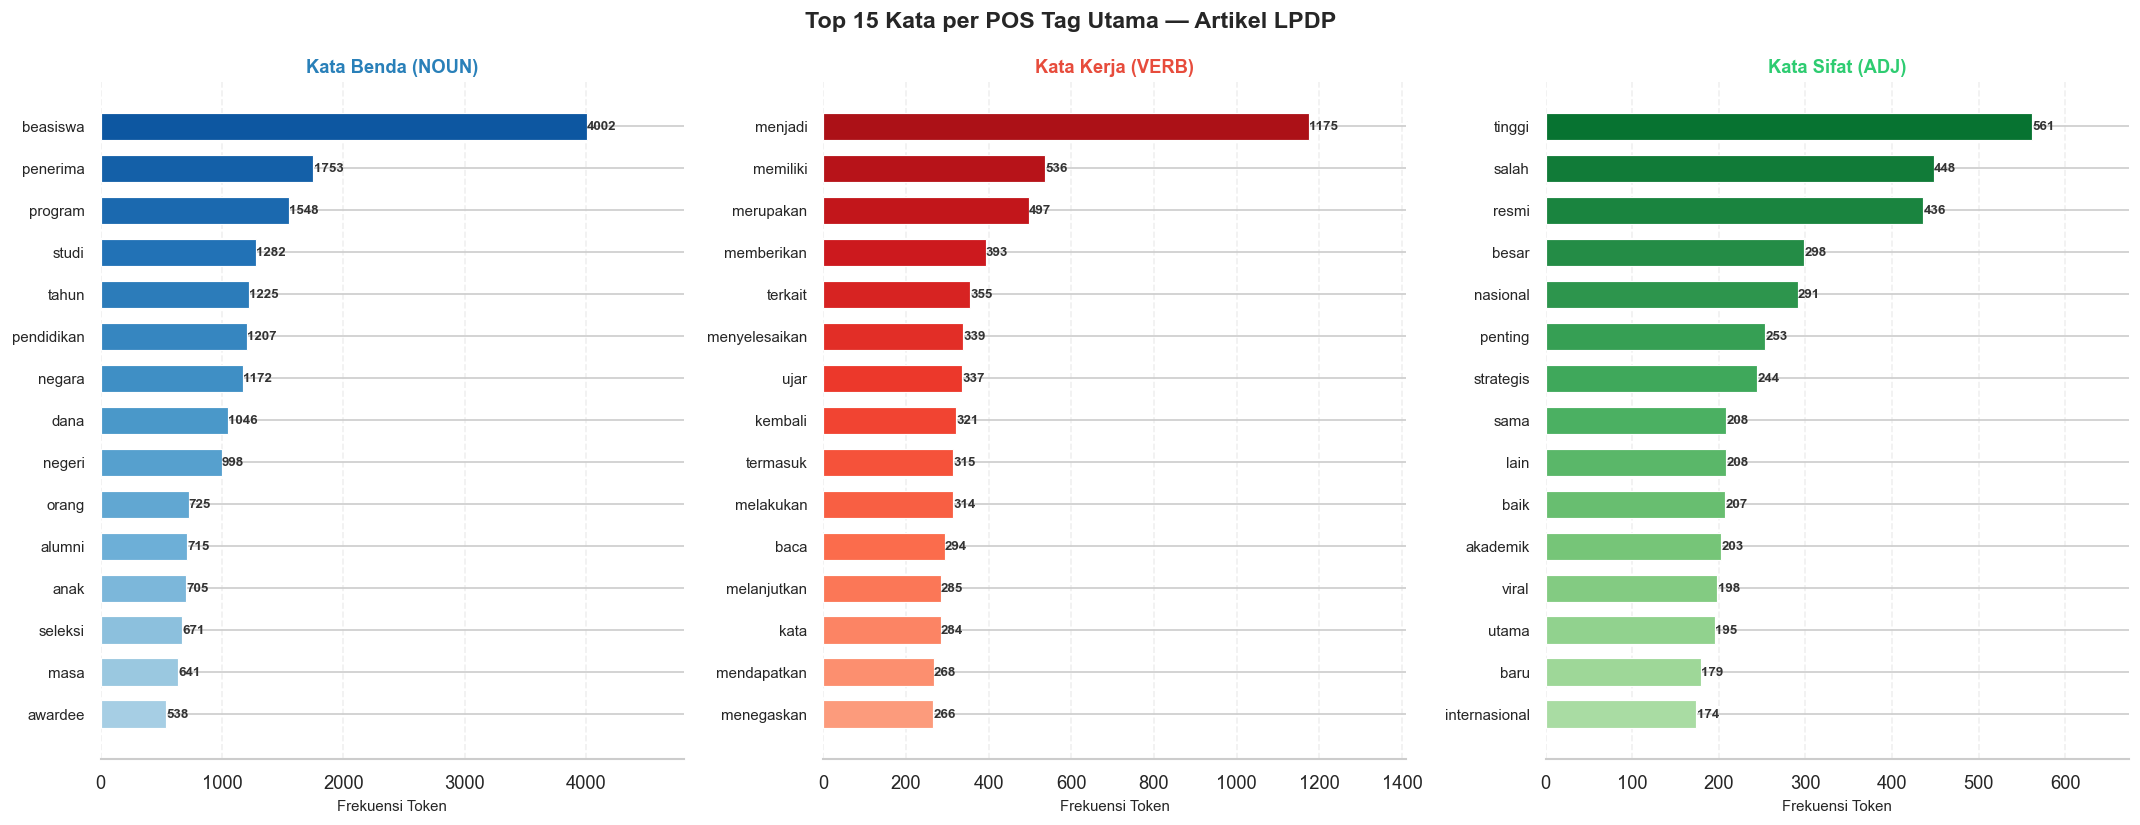

💾 Disimpan: output_pos_tagging\pos_top_kata_noun_verb_adj.png


In [9]:
TOP_N = 15

STOP_TOKENS = {
    'yang', 'di', 'dan', 'ke', 'dari', 'ini', 'itu', 'ada',
    'dengan', 'untuk', 'pada', 'dalam', 'tidak', 'juga', 'sudah',
    'akan', 'oleh', 'telah', 'bisa', 'saat', 'lagi', 'ya', 'nya',
}

FOCUS_POS = ['NOUN', 'VERB', 'ADJ']
POS_LABEL = {'NOUN': 'Kata Benda (NOUN)', 'VERB': 'Kata Kerja (VERB)', 'ADJ': 'Kata Sifat (ADJ)'}
POS_CMAP  = {'NOUN': 'Blues', 'VERB': 'Reds', 'ADJ': 'Greens'}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle(f'Top {TOP_N} Kata per POS Tag Utama — Artikel LPDP', fontsize=14, fontweight='bold')

for idx, pos in enumerate(FOCUS_POS):
    ax = axes[idx]
    df_pos_filtered = df_pos[
        (df_pos['upos'] == pos) &
        (~df_pos['token'].str.lower().isin(STOP_TOKENS)) &
        (df_pos['token'].str.len() >= 3)
    ].copy()

    top_words = (
        df_pos_filtered['token']
        .dropna()
        .astype(str)
        .str.lower()
        .value_counts()
        .head(TOP_N)
        .sort_values(ascending=True)
    )

    if top_words.empty:
        ax.set_title(POS_LABEL[pos], fontsize=11, fontweight='bold', color=PALETTE_POS.get(pos, '#333'))
        ax.text(0.5, 0.5, 'Tidak ada data', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='gray')
        ax.axis('off')
        continue

    n_words = len(top_words)
    cmap    = plt.cm.get_cmap(POS_CMAP[pos])
    colors  = cmap(np.linspace(0.35, 0.85, n_words))

    bars = ax.barh(
        top_words.index, top_words.values,
        color=colors, edgecolor='white', linewidth=0.7, height=0.65
    )
    for bar, val in zip(bars, top_words.values):
        ax.text(
            bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', ha='left', fontsize=8, fontweight='bold', color='#333'
        )

    ax.set_title(POS_LABEL[pos], fontsize=11, fontweight='bold', color=PALETTE_POS.get(pos, '#333'))
    ax.set_xlabel('Frekuensi Token', fontsize=9)
    ax.set_xlim(0, top_words.values.max() * 1.2)
    ax.tick_params(axis='y', labelsize=9)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.xaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
out_path = OUTPUT_DIR / 'pos_top_kata_noun_verb_adj.png'
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f"💾 Disimpan: {out_path}")

## 📊 Part 4: Analisis POS per Sentimen

### 4.1 Distribusi Rasio POS per Sentimen

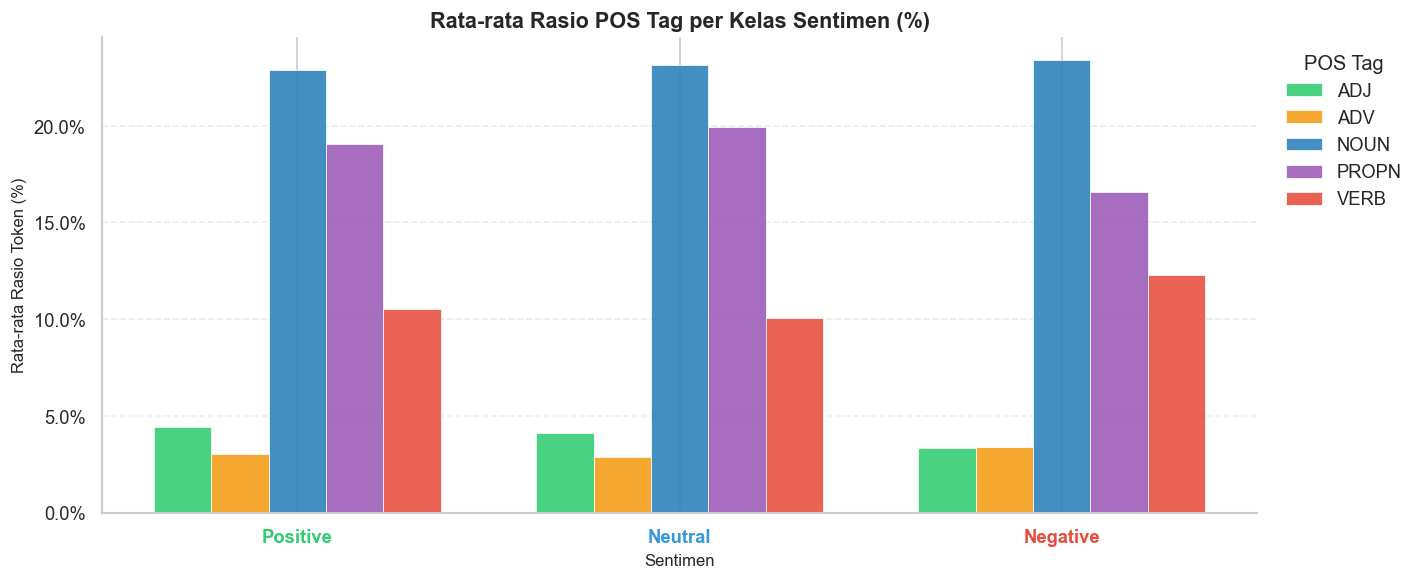

💾 Disimpan: output_pos_tagging\pos_rasio_per_sentimen.png


In [10]:
PALETTE_SENTIMENT = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}

# Hitung rasio POS per artikel, lalu rata-ratakan per sentimen
pos_per_doc = (
    df_pos.groupby(['doc_id', 'Sentiment', 'upos'])
    .size()
    .reset_index(name='count')
)

total_per_doc = (
    df_pos.groupby('doc_id')['upos']
    .count()
    .reset_index(name='total')
)

pos_per_doc = pos_per_doc.merge(total_per_doc, on='doc_id')
pos_per_doc['ratio'] = pos_per_doc['count'] / pos_per_doc['total'] * 100

# Rata-rata rasio per sentimen & POS
pos_sentiment_avg = (
    pos_per_doc[pos_per_doc['upos'].isin(FOCUS_POS + ['ADV', 'PROPN'])]
    .groupby(['Sentiment', 'upos'])['ratio']
    .mean()
    .unstack(fill_value=0)
    .reindex(index=['Positive', 'Neutral', 'Negative'])
)

fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(pos_sentiment_avg.index))
width = 0.15

for i, pos_tag in enumerate(pos_sentiment_avg.columns):
    offset = (i - len(pos_sentiment_avg.columns) / 2) * width
    bars   = ax.bar(
        x + offset + width / 2,
        pos_sentiment_avg[pos_tag],
        width=width, label=pos_tag,
        color=PALETTE_POS.get(pos_tag, '#bdc3c7'),
        edgecolor='white', linewidth=0.5, alpha=0.88
    )

ax.set_title('Rata-rata Rasio POS Tag per Kelas Sentimen (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Sentimen', fontsize=10)
ax.set_ylabel('Rata-rata Rasio Token (%)', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(pos_sentiment_avg.index, fontsize=11, fontweight='bold')
tick_colors = ['#2ecc71', '#3498db', '#e74c3c']
for tick, color in zip(ax.get_xticklabels(), tick_colors):
    tick.set_color(color)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title='POS Tag', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
out_path = OUTPUT_DIR / 'pos_rasio_per_sentimen.png'
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f"💾 Disimpan: {out_path}")

### 4.2 Heatmap POS Tag vs Sentimen

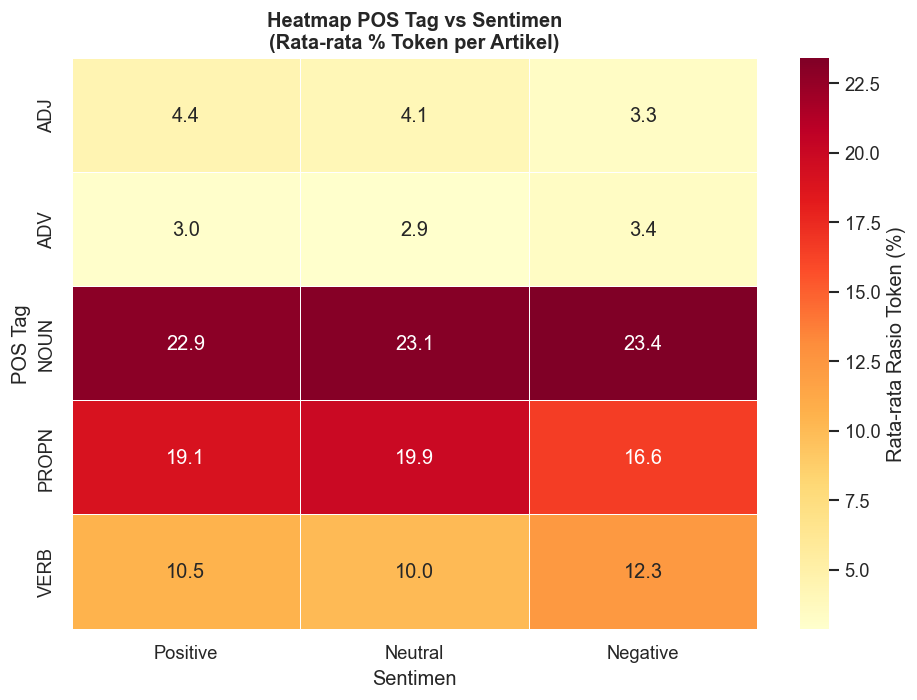

💾 Disimpan: output_pos_tagging\pos_heatmap_pos_sentimen.png


In [11]:
# Pivot: rata-rata rasio POS per sentimen
heat_sent = pos_sentiment_avg.T  # Transpose: POS jadi baris, sentimen jadi kolom

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    heat_sent,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Rata-rata Rasio Token (%)'}
)
ax.set_title('Heatmap POS Tag vs Sentimen\n(Rata-rata % Token per Artikel)', fontsize=12, fontweight='bold')
ax.set_xlabel('Sentimen')
ax.set_ylabel('POS Tag')
plt.tight_layout()
out_path = OUTPUT_DIR / 'pos_heatmap_pos_sentimen.png'
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f"💾 Disimpan: {out_path}")

### 4.3 Top Kata ADJ per Sentimen (Kata Sifat Paling Dominan)

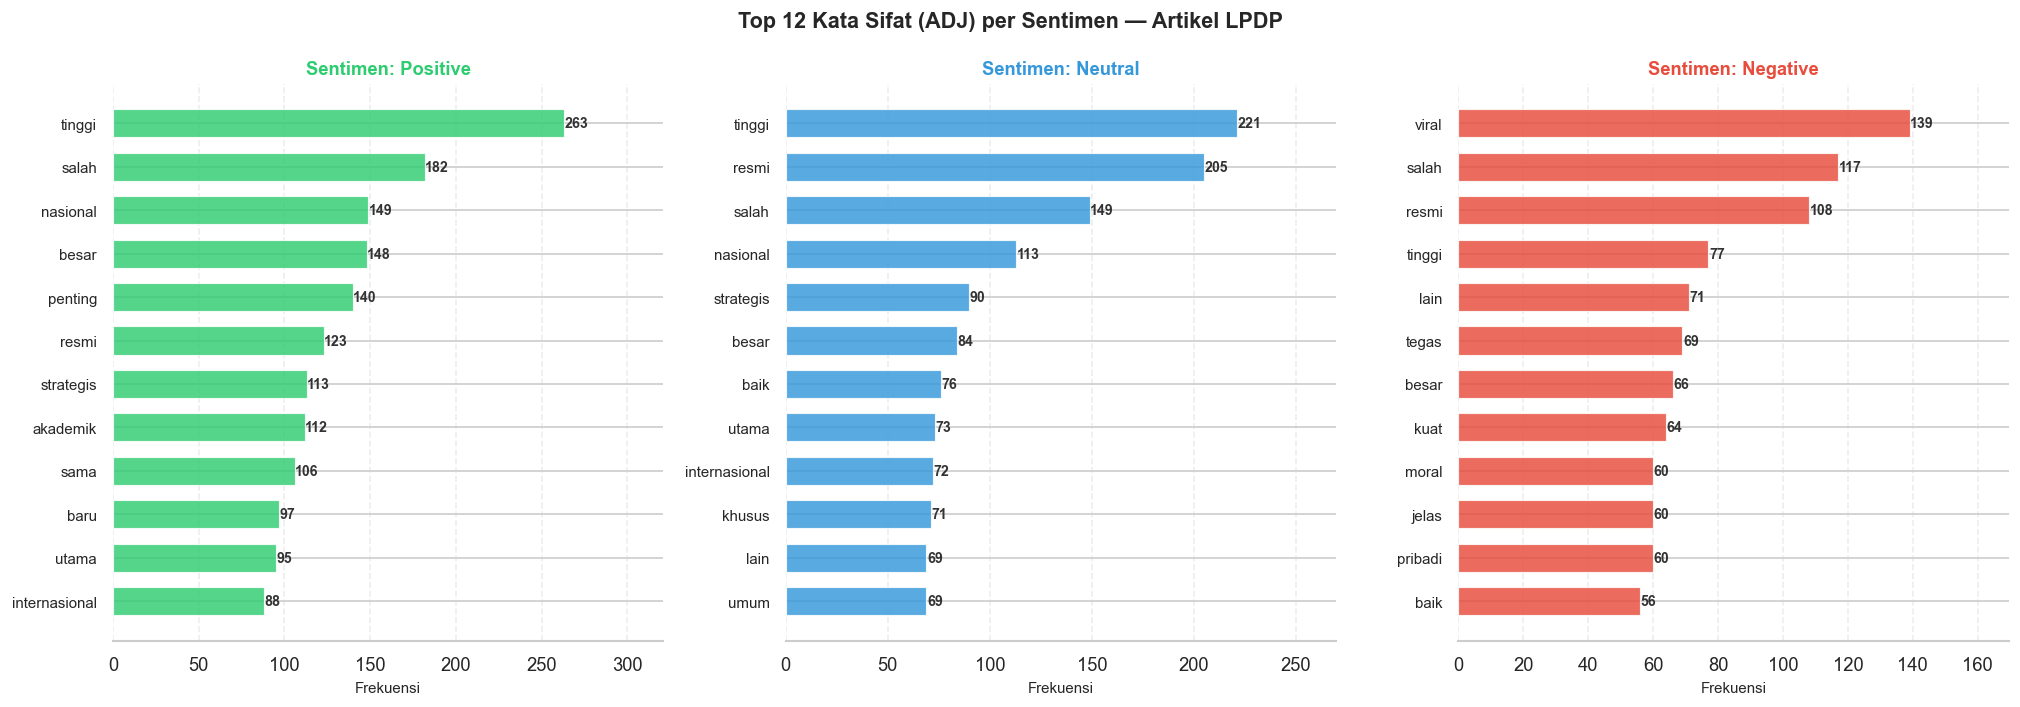

💾 Disimpan: output_pos_tagging\pos_top_adj_per_sentimen.png


In [12]:
TOP_ADJ = 12
sentimen_list = ['Positive', 'Neutral', 'Negative']

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle(f'Top {TOP_ADJ} Kata Sifat (ADJ) per Sentimen — Artikel LPDP',
             fontsize=13, fontweight='bold')

for idx, sentiment in enumerate(sentimen_list):
    ax = axes[idx]
    df_adj = df_pos[
        (df_pos['upos'] == 'ADJ') &
        (df_pos['Sentiment'] == sentiment) &
        (df_pos['token'].str.len() >= 3) &
        (~df_pos['token'].str.lower().isin(STOP_TOKENS))
    ]
    top_adj = (
        df_adj['token'].str.lower()
        .value_counts()
        .head(TOP_ADJ)
        .sort_values(ascending=True)
    )

    color = PALETTE_SENTIMENT[sentiment]
    bars  = ax.barh(
        top_adj.index, top_adj.values,
        color=color, alpha=0.82,
        edgecolor='white', linewidth=0.7, height=0.65
    )
    for bar, val in zip(bars, top_adj.values):
        ax.text(
            bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', ha='left', fontsize=8.5,
            color='#333', fontweight='bold'
        )

    ax.set_title(f'Sentimen: {sentiment}', fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Frekuensi', fontsize=9)
    ax.set_xlim(0, top_adj.values.max() * 1.22)
    ax.tick_params(axis='y', labelsize=9)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.xaxis.grid(True, linestyle='--', alpha=0.35)
    ax.set_axisbelow(True)

plt.tight_layout()
out_path = OUTPUT_DIR / 'pos_top_adj_per_sentimen.png'
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f"💾 Disimpan: {out_path}")

## 📊 Part 5: Analisis POS per Topik

### 5.1 Rasio POS per Topik BERTopic

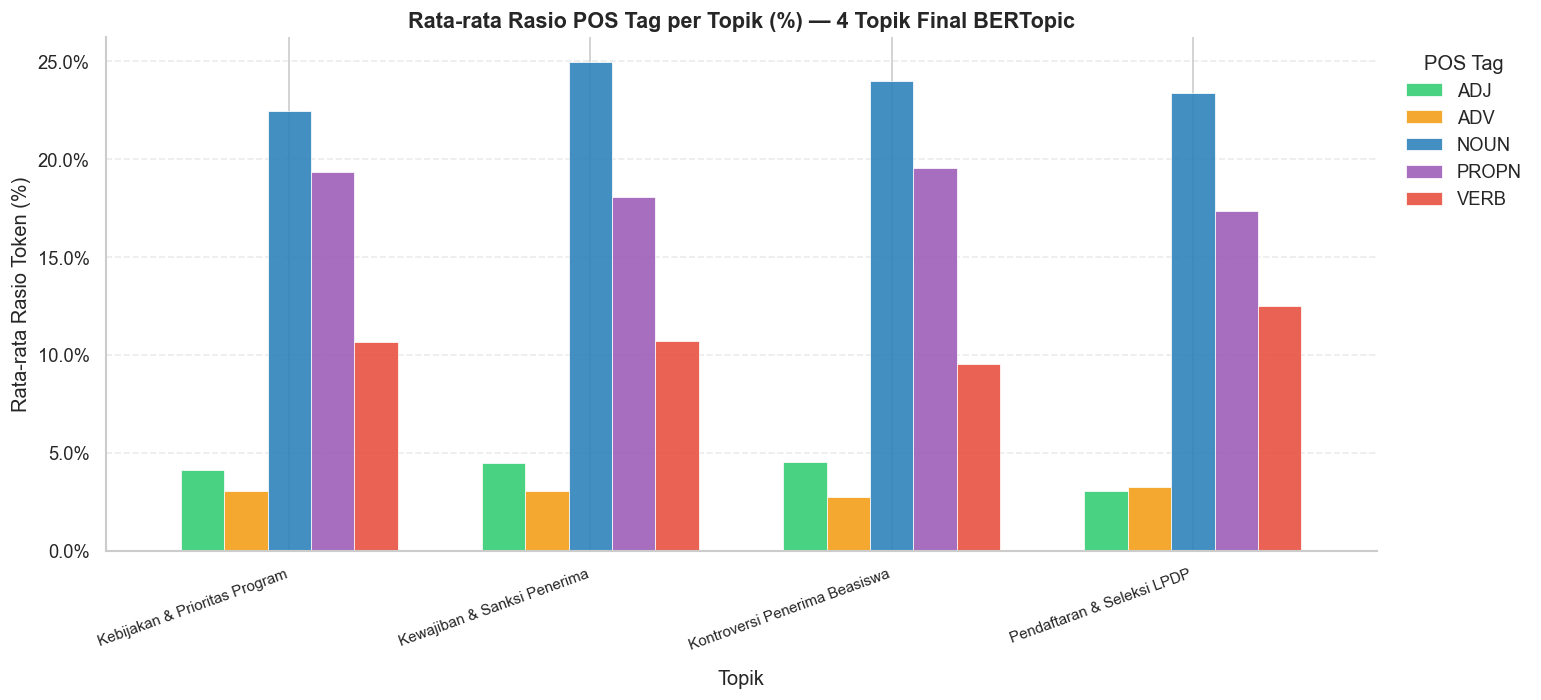

💾 Disimpan: output_pos_tagging\pos_rasio_per_topik.png


In [13]:
df_pos_valid_topic = df_pos.dropna(subset=['topic_label'])

# Hitung rata-rata rasio POS per topik
pos_per_doc_topic = (
    df_pos_valid_topic.groupby(['doc_id', 'topic_label', 'upos'])
    .size()
    .reset_index(name='count')
)
total_per_doc_topic = (
    df_pos_valid_topic.groupby('doc_id')['upos']
    .count()
    .reset_index(name='total')
)
pos_per_doc_topic = pos_per_doc_topic.merge(total_per_doc_topic, on='doc_id')
pos_per_doc_topic['ratio'] = pos_per_doc_topic['count'] / pos_per_doc_topic['total'] * 100

pos_topic_avg = (
    pos_per_doc_topic[pos_per_doc_topic['upos'].isin(FOCUS_POS + ['ADV', 'PROPN'])]
    .groupby(['topic_label', 'upos'])['ratio']
    .mean()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 6))
pos_topic_avg.plot(
    kind='bar',
    color=[PALETTE_POS.get(c, '#bdc3c7') for c in pos_topic_avg.columns],
    ax=ax, edgecolor='white', linewidth=0.5, width=0.72, alpha=0.88
)
ax.set_title('Rata-rata Rasio POS Tag per Topik (%) — 4 Topik Final BERTopic',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Topik', labelpad=10)
ax.set_ylabel('Rata-rata Rasio Token (%)')
ax.set_xticklabels(pos_topic_avg.index, rotation=20, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title='POS Tag', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
out_path = OUTPUT_DIR / 'pos_rasio_per_topik.png'
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f"💾 Disimpan: {out_path}")

### 5.2 Heatmap POS Tag vs Topik

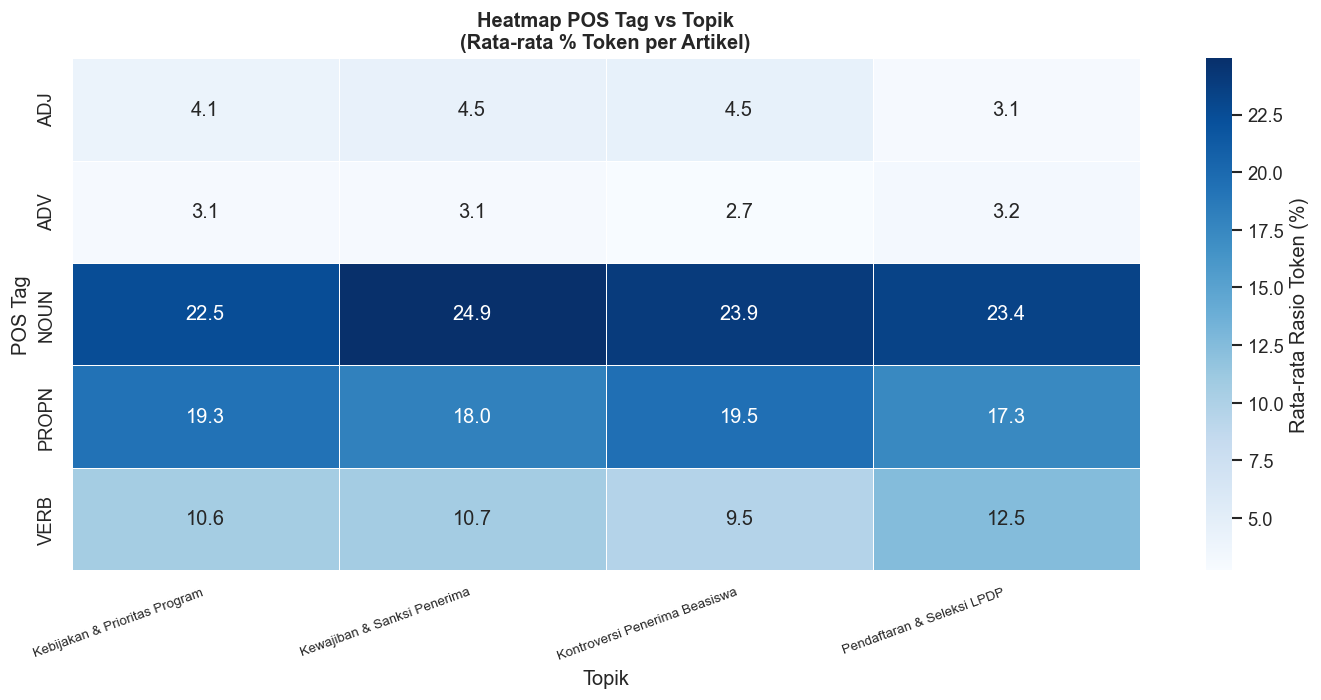

💾 Disimpan: output_pos_tagging\pos_heatmap_pos_topik.png


In [14]:
heat_topic = pos_topic_avg.T  # POS jadi baris, topik jadi kolom

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    heat_topic,
    annot=True, fmt='.1f', cmap='Blues',
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Rata-rata Rasio Token (%)'}
)
ax.set_title('Heatmap POS Tag vs Topik\n(Rata-rata % Token per Artikel)', fontsize=12, fontweight='bold')
ax.set_xlabel('Topik')
ax.set_ylabel('POS Tag')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
plt.tight_layout()
out_path = OUTPUT_DIR / 'pos_heatmap_pos_topik.png'
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f"💾 Disimpan: {out_path}")

## 📊 Part 6: Word Cloud per POS Tag

### 6.1 Word Cloud NOUN, VERB, ADJ

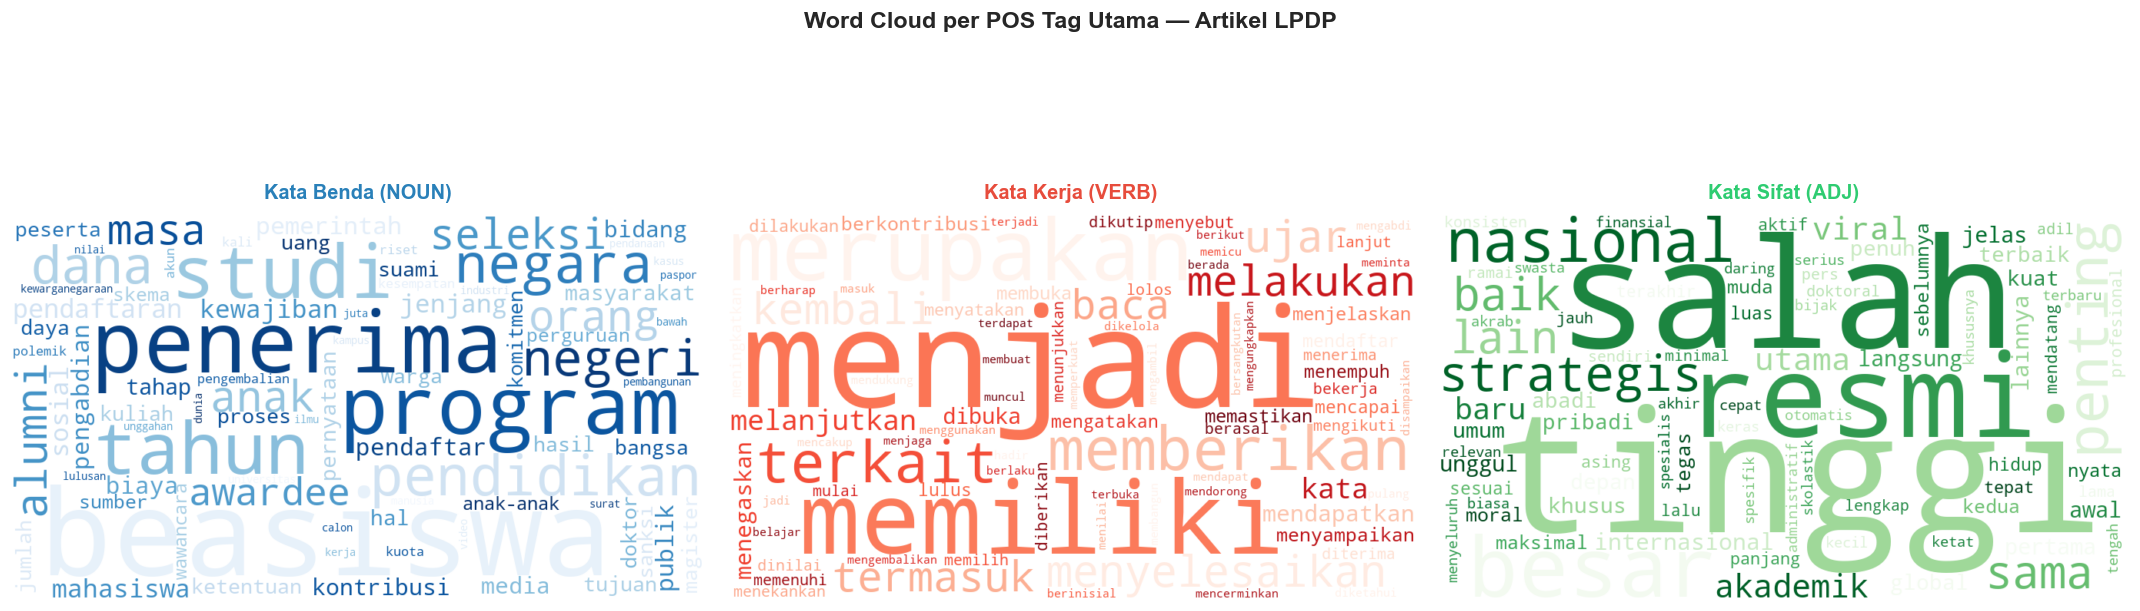

💾 Disimpan: output_pos_tagging\pos_wordcloud_noun_verb_adj.png


In [15]:
WC_CONFIG = {
    'NOUN' : {'cmap': 'Blues',  'label': 'Kata Benda (NOUN)'},
    'VERB' : {'cmap': 'Reds',   'label': 'Kata Kerja (VERB)'},
    'ADJ'  : {'cmap': 'Greens', 'label': 'Kata Sifat (ADJ)'},
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Word Cloud per POS Tag Utama — Artikel LPDP',
             fontsize=14, fontweight='bold', y=1.02)

for idx, (pos_tag, cfg) in enumerate(WC_CONFIG.items()):
    ax = axes[idx]
    df_wc = df_pos[
        (df_pos['upos'] == pos_tag) &
        (df_pos['token'].str.len() >= 3) &
        (~df_pos['token'].str.lower().isin(STOP_TOKENS))
    ]

    freq_dict = df_wc['token'].dropna().astype(str).str.lower().value_counts().to_dict()

    wc = WordCloud(
        width=900, height=500,
        background_color='white',
        colormap=cfg['cmap'],
        max_words=80,
        collocations=False,
        min_font_size=10,
    ).generate_from_frequencies(freq_dict)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(cfg['label'], fontsize=12, fontweight='bold',
                 color=PALETTE_POS.get(pos_tag, '#333'), pad=10)
    ax.axis('off')

plt.tight_layout()
out_path = OUTPUT_DIR / 'pos_wordcloud_noun_verb_adj.png'
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f"💾 Disimpan: {out_path}")

## 💾 Part 7: Export Hasil POS Tagging

### 7.1 Simpan Ringkasan ke Excel

In [16]:
summary_excel_path = OUTPUT_DIR / "pos_summary.xlsx"

# === Sheet 1: Semua token ===
# === Sheet 2: Distribusi POS overall ===
pos_dist_df = pos_counts.reset_index()
pos_dist_df.columns = ['upos', 'jumlah_token']
pos_dist_df['persen'] = (pos_dist_df['jumlah_token'] / total_tokens * 100).round(2)

# === Sheet 3: Top kata per POS ===
top_words_per_pos = {}
for pos_tag in FOCUS_POS + ['ADV', 'PROPN']:
    top_words_per_pos[pos_tag] = (
        df_pos[
            (df_pos['upos'] == pos_tag) &
            (df_pos['token'].str.len() >= 3) &
            (~df_pos['token'].str.lower().isin(STOP_TOKENS))
        ]['token']
        .str.lower()
        .value_counts()
        .head(30)
        .reset_index()
    )
    top_words_per_pos[pos_tag].columns = ['token', 'frekuensi']
    top_words_per_pos[pos_tag]['upos'] = pos_tag

# === Sheet 4: Rata-rata rasio POS per sentimen ===
pos_sentiment_export = pos_sentiment_avg.round(2).reset_index()

# === Sheet 5: Rata-rata rasio POS per topik ===
pos_topic_export = pos_topic_avg.round(2).reset_index()

with pd.ExcelWriter(summary_excel_path, engine='openpyxl') as writer:
    df_pos.to_excel(writer, sheet_name='All_Tokens', index=False)
    pos_dist_df.to_excel(writer, sheet_name='Distribusi_POS', index=False)
    for pos_tag, df_top in top_words_per_pos.items():
        df_top.to_excel(writer, sheet_name=f'Top_{pos_tag}', index=False)
    pos_sentiment_export.to_excel(writer, sheet_name='POS_per_Sentimen', index=False)
    pos_topic_export.to_excel(writer, sheet_name='POS_per_Topik', index=False)

print(f"💾 Tersimpan: {summary_excel_path}")
print(f"   Sheet yang dihasilkan: All_Tokens | Distribusi_POS | Top_NOUN | Top_VERB | Top_ADJ | Top_ADV | Top_PROPN | POS_per_Sentimen | POS_per_Topik")

💾 Tersimpan: output_pos_tagging\pos_summary.xlsx
   Sheet yang dihasilkan: All_Tokens | Distribusi_POS | Top_NOUN | Top_VERB | Top_ADJ | Top_ADV | Top_PROPN | POS_per_Sentimen | POS_per_Topik


## 📋 Part 8: Ringkasan Analisis Komprehensif

In [17]:
print("=" * 70)
print("📋 RINGKASAN ANALISIS — POS TAGGING ARTIKEL LPDP")
print("=" * 70)

print(f"\n📦 Total Artikel Diproses : {df_pos['doc_id'].nunique()}")
print(f"   Total Token            : {len(df_pos):,}")
print(f"   Rata-rata token/artikel: {len(df_pos) / df_pos['doc_id'].nunique():.1f}")

print(f"\n📊 Distribusi POS Tag:")
for pos, cnt in pos_counts.items():
    print(f"   {pos:<10}: {cnt:>8,} token ({cnt/total_tokens*100:>5.1f}%)")

print(f"\n📌 Top 5 Kata per POS Tag Utama:")
for pos_tag in FOCUS_POS:
    top5 = (
        df_pos[
            (df_pos['upos'] == pos_tag) &
            (df_pos['token'].str.len() >= 3) &
            (~df_pos['token'].str.lower().isin(STOP_TOKENS))
        ]['token']
        .str.lower()
        .value_counts()
        .head(5)
    )
    print(f"\n   [{pos_tag}]")
    for word, cnt in top5.items():
        print(f"   {word:<25}: {cnt} token")

print(f"\n📁 File Output:")
for f_out in sorted(OUTPUT_DIR.iterdir()):
    size_kb = f_out.stat().st_size / 1024
    print(f"   {f_out.name:<55} ({size_kb:.1f} KB)")

print("=" * 70)
print("✅ Phase 7 selesai!")

📋 RINGKASAN ANALISIS — POS TAGGING ARTIKEL LPDP

📦 Total Artikel Diproses : 1038
   Total Token            : 338,257
   Rata-rata token/artikel: 325.9

📊 Distribusi POS Tag:
   NOUN      :   78,235 token ( 23.1%)
   PROPN     :   62,209 token ( 18.4%)
   PUNCT     :   48,832 token ( 14.4%)
   VERB      :   36,568 token ( 10.8%)
   ADP       :   26,998 token (  8.0%)
   PRON      :   16,450 token (  4.9%)
   ADJ       :   13,368 token (  4.0%)
   NUM       :   10,457 token (  3.1%)
   ADV       :   10,202 token (  3.0%)
   DET       :    8,855 token (  2.6%)
   CCONJ     :    8,154 token (  2.4%)
   SCONJ     :    6,490 token (  1.9%)
   AUX       :    5,861 token (  1.7%)
   PART      :    3,755 token (  1.1%)
   X         :    1,619 token (  0.5%)
   SYM       :      193 token (  0.1%)
   INTJ      :       11 token (  0.0%)

📌 Top 5 Kata per POS Tag Utama:

   [NOUN]
   beasiswa                 : 4002 token
   penerima                 : 1753 token
   program                  : 1548 to

## 📝 Catatan Lanjutan

### Output Phase 7 → Input Phase Berikutnya

| File | Digunakan Untuk |
|---|---|
| `output_pos_tagging/pos_results.csv` | Analisis linguistik lanjutan, laporan akhir |
| `output_pos_tagging/pos_summary.xlsx` | Tabel hasil presentasi & ringkasan |
| `output_pos_tagging/*.png` | Visualisasi untuk laporan & slide |